# ============================================
# 1. (Импорт библиотек и чтение файла)
# ============================================

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('dark_background')

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a',
    'axes.facecolor':   '#14141f',
    'axes.edgecolor':   '#2a2a3a',
    'axes.labelcolor':  '#ccccdd',
    'xtick.color':      '#888899',
    'ytick.color':      '#888899',
    'text.color':       '#eeeeee',
    'grid.color':       '#1e1e2e',
})

COLORS = ['#FFD700','#00B4D8','#57EE9A','#E63946','#C77DFF','#FF6B6B']

In [2]:
data = pd.read_csv('../data/raw/genz_social_media_usage_1M.csv')

# ============================================
# 2. EDA (РАЗВЕДЫВАТЕЛЬНЫЙ АНАЛИЗ)
# ============================================

In [3]:
data.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [4]:
data.shape

(1000000, 12)

In [5]:
print(f"There are {data.duplicated().sum()} duplicated values in the dataset")

There are 0 duplicated values in the dataset


In [6]:
data.isna().sum()

age                         0
gender                      0
country                     0
daily_usage_hours           0
primary_platform            0
num_platforms_used          0
purpose                     0
avg_session_minutes         0
night_usage                 0
mental_health_score         0
addiction_level             0
screen_time_before_sleep    0
dtype: int64

In [7]:
data.dtypes

age                           int64
gender                          str
country                         str
daily_usage_hours           float64
primary_platform                str
num_platforms_used            int64
purpose                         str
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level                 str
screen_time_before_sleep    float64
dtype: object

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 12 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   gender                    1000000 non-null  str    
 2   country                   1000000 non-null  str    
 3   daily_usage_hours         1000000 non-null  float64
 4   primary_platform          1000000 non-null  str    
 5   num_platforms_used        1000000 non-null  int64  
 6   purpose                   1000000 non-null  str    
 7   avg_session_minutes       1000000 non-null  float64
 8   night_usage               1000000 non-null  int64  
 9   mental_health_score       1000000 non-null  float64
 10  addiction_level           1000000 non-null  str    
 11  screen_time_before_sleep  1000000 non-null  float64
dtypes: float64(4), int64(3), str(5)
memory usage: 91.6 MB


In [9]:
data.describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


In [10]:
cat_columns = data.select_dtypes(include=['object']).columns
cat_columns


Index(['gender', 'country', 'primary_platform', 'purpose', 'addiction_level'], dtype='str')

In [11]:
for col in cat_columns:
    print(f"{col}:")
    print(data[col].value_counts().head(5))

gender:
gender
Female    480113
Male      479576
Other      40311
Name: count, dtype: int64
country:
country
India      350321
USA        199740
Canada     100384
UK         100343
Germany     99896
Name: count, dtype: int64
primary_platform:
primary_platform
Instagram    299927
YouTube      250292
TikTok       250085
Twitter      100022
Snapchat      99674
Name: count, dtype: int64
purpose:
purpose
Entertainment       400052
Socializing         250239
Education           200367
News                 99693
Content Creation     49649
Name: count, dtype: int64
addiction_level:
addiction_level
Medium    589843
Low       251220
High      158937
Name: count, dtype: int64


In [12]:
num_cols = data.select_dtypes(include=['int', 'float']).columns

In [13]:
data[num_cols].describe()

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719


# ============================================
# 3. ВИЗУАЛИЗАЦИИ
# ============================================

Text(0.5, 1.0, 'Распределение часов использования в день')

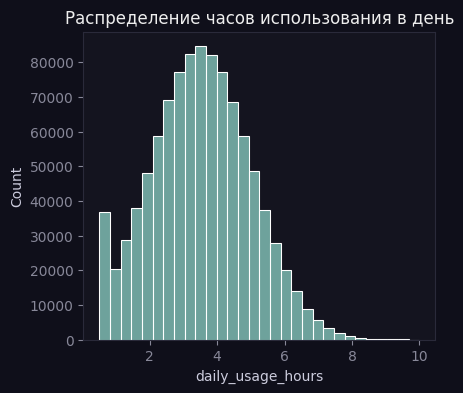

In [14]:
#1) Распределение daily_usage_hours

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(data['daily_usage_hours'], bins=30)
plt.title('Распределение часов использования в день')


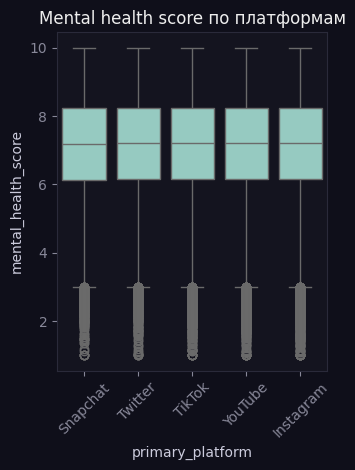

In [15]:
# 2. Mental health по платформам
plt.subplot(1,2,2)
sns.boxplot(data=data, x='primary_platform', y='mental_health_score')
plt.xticks(rotation=45)
plt.title('Mental health score по платформам')
plt.tight_layout()
plt.show()

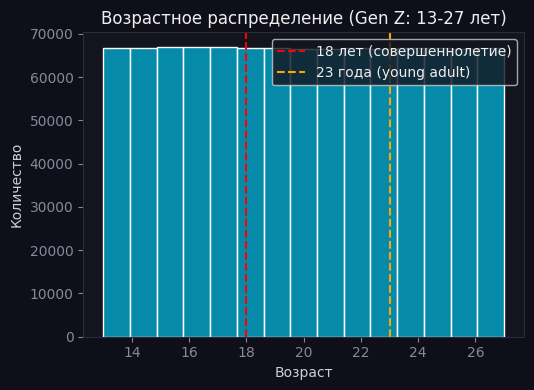

In [16]:
# 3) График: Распределение возраста (Gen Z специфика)
plt.figure(figsize=(10,4))
plt.subplot(1,2,2)
sns.histplot(data['age'], bins=15, color=COLORS[1])
plt.title('Возрастное распределение (Gen Z: 13-27 лет)')
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.axvline(x=18, color='red', linestyle='--', label='18 лет (совершеннолетие)')
plt.axvline(x=23, color='orange', linestyle='--', label='23 года (young adult)')
plt.legend()
plt.tight_layout()
plt.show()

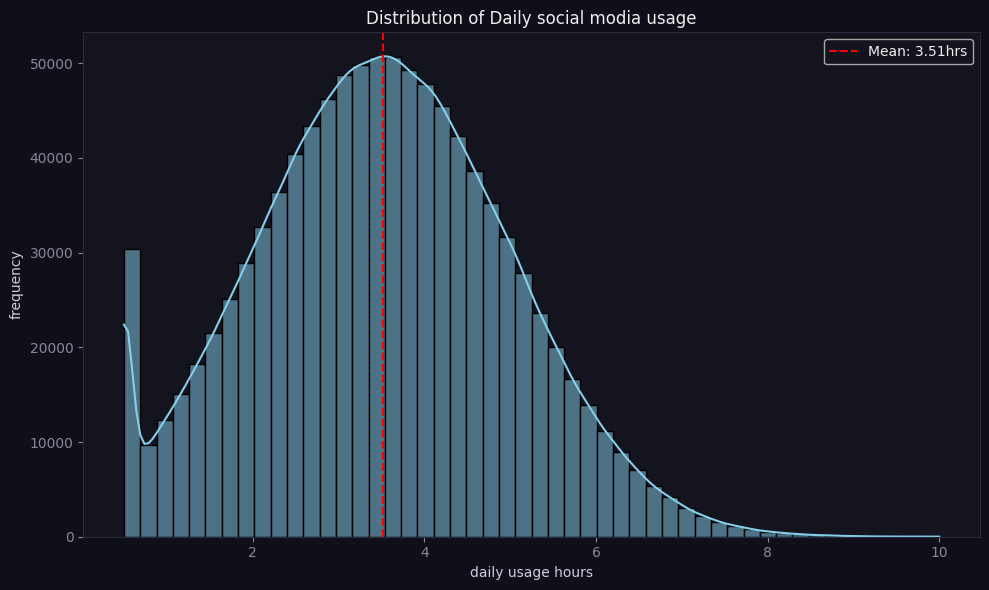

In [17]:
plt.figure(figsize=(10,6))
sns.histplot(data['daily_usage_hours'], bins=50, kde=True, color='skyblue', edgecolor='black')
plt.title('Distribution of Daily social modia usage')
plt.xlabel('daily usage hours')
plt.ylabel('frequency')
plt.axvline(data['daily_usage_hours'].mean(), color='red', linestyle='--', label=f"Mean: {data['daily_usage_hours'].mean():.2f}hrs")
plt.legend()
plt.tight_layout()
plt.show()

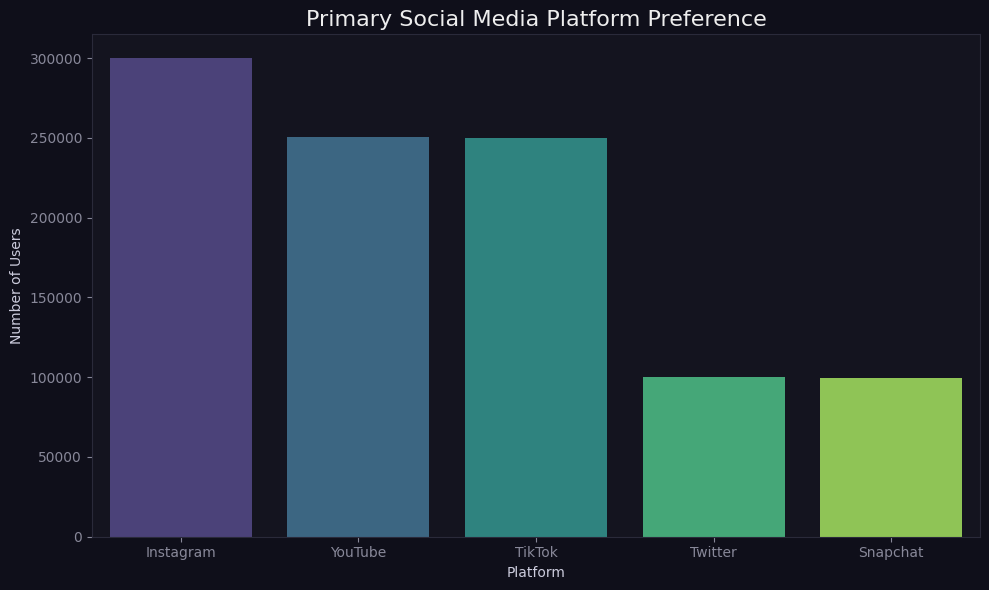

In [18]:
plt.figure(figsize=(10,6))
plaform_order = data['primary_platform'].value_counts().index
sns.countplot(data=data, x = 'primary_platform', order=plaform_order, palette='viridis')
plt.title('Primary Social Media Platform Preference', fontsize=16)
plt.xlabel('Platform')
plt.ylabel('Number of Users')
plt.tight_layout()
plt.show()
plt.show()


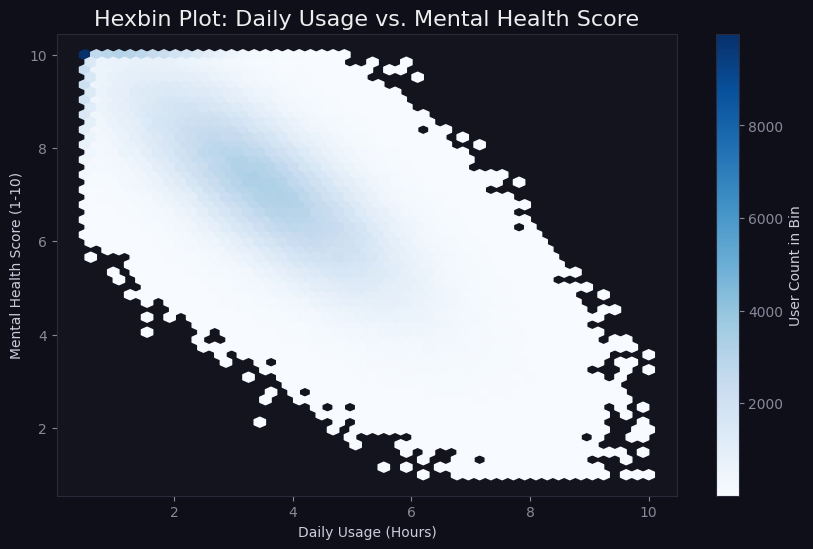

In [19]:
plt.figure(figsize=(10, 6))
plt.hexbin(data['daily_usage_hours'], data['mental_health_score'], gridsize=50, cmap='Blues', mincnt=1)
plt.colorbar(label='User Count in Bin')
plt.title('Hexbin Plot: Daily Usage vs. Mental Health Score', fontsize=16)
plt.xlabel('Daily Usage (Hours)')
plt.ylabel('Mental Health Score (1-10)')
plt.show()

In [20]:
plt.figure(figsize=(10,6))
addiction_gender = pd.crosstab(data['gender'], data['addiction_level'], normalize='index') * 100
addiction_gender

addiction_level,High,Low,Medium
gender,,,
Female,15.912712,25.144706,58.942582
Male,15.858175,25.100714,59.041111
Other,16.089901,25.104810,58.805289


<Figure size 1000x600 with 0 Axes>

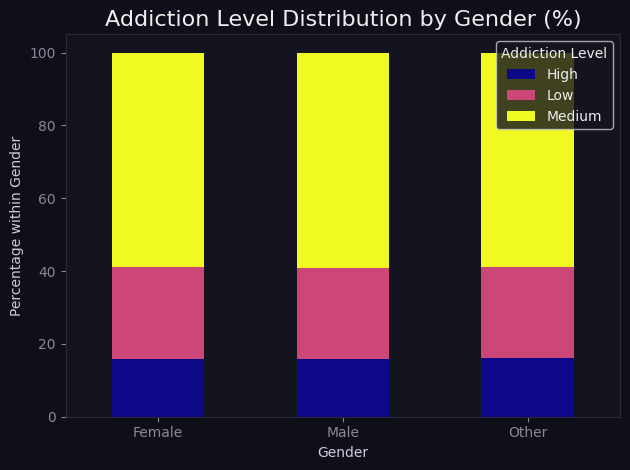

In [21]:
addiction_gender.plot(kind='bar', stacked=True, colormap='plasma')
plt.title('Addiction Level Distribution by Gender (%)', fontsize=16)
plt.xlabel('Gender')
plt.ylabel('Percentage within Gender')
plt.xticks(rotation=0)
plt.legend(title='Addiction Level')
plt.tight_layout()
plt.show()

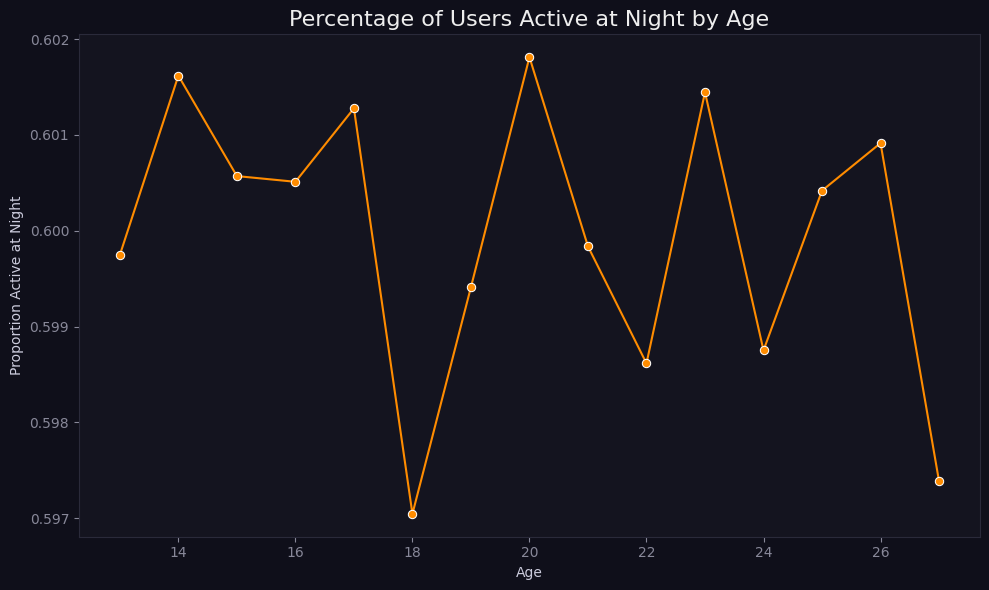

In [22]:
plt.figure(figsize=(10,6))
night_usage_by_age = data.groupby('age')['night_usage'].mean()
sns.lineplot(x=night_usage_by_age.index,y=night_usage_by_age.values,marker='o',color='darkorange')
plt.title('Percentage of Users Active at Night by Age', fontsize=16)
plt.xlabel('Age')
plt.ylabel('Proportion Active at Night')
plt.tight_layout()
plt.show()

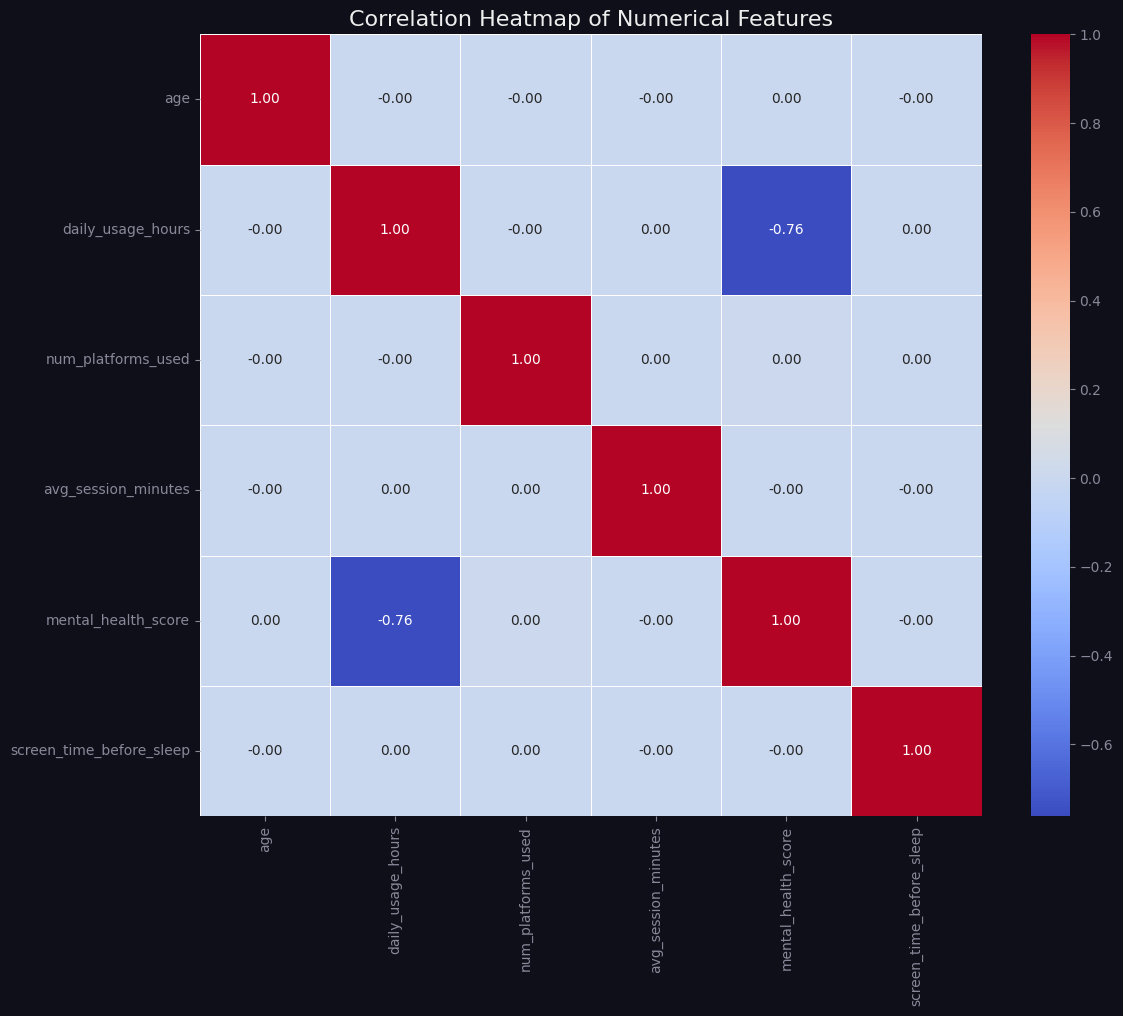

In [23]:
numerical_cols = ['age', 'daily_usage_hours', 'num_platforms_used', 
                  'avg_session_minutes', 'mental_health_score', 
                  'screen_time_before_sleep']

plt.figure(figsize=(12, 10))
corr_matrix = data[numerical_cols].corr()
# annot=True displays the correlation coefficient values

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler

ordinal_cols = ['addiction_level']
ord_en = OrdinalEncoder()
data[ordinal_cols] = ord_en.fit_transform(data[ordinal_cols])

nominal_cols = ['gender', 'country','primary_platform','purpose']
df_encoded = pd.get_dummies(data, columns=nominal_cols, drop_first=True, dtype=int)

scaler = MinMaxScaler()

numerical_cols = ['age','num_platforms_used',
                'daily_usage_hours','avg_session_minutes','night_usage',
                'mental_health_score','screen_time_before_sleep','addiction_level'
                ]
df_encoded[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

df_encoded.head(5)

,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep,gender_Male,gender_Other,...,country_UK,country_USA,primary_platform_Snapchat,primary_platform_TikTok,primary_platform_Twitter,primary_platform_YouTube,purpose_Education,purpose_Entertainment,purpose_News,purpose_Socializing
0,0.428571,0.227223,0.75,0.321841,0.0,0.633981,1.0,0.114345,1,0,...,0,0,1,0,0,0,1,0,0,0
1,0.214286,0.545830,0.50,0.364920,1.0,0.625901,0.0,0.345763,0,0,...,0,1,0,0,1,0,0,0,0,1
2,0.857143,0.240255,0.25,0.174991,1.0,0.559489,1.0,0.453081,0,0,...,0,0,0,1,0,0,0,0,0,1
3,1.000000,0.314379,0.75,0.232438,1.0,0.790096,1.0,0.231416,1,0,...,0,0,0,0,0,1,1,0,0,0
4,0.714286,0.341982,0.00,0.297073,1.0,0.628733,1.0,0.213524,0,0,...,0,0,0,1,0,0,0,1,0,0


Model                          | MAE        | RMSE       | R2 Score  
---------------------------------------------------------------------------
Linear Regression              | 0.3482     | 0.3651     | 0.0534    
Ridge Regression               | 0.3482     | 0.3651     | 0.0534    
Lasso Regression               | 0.3358     | 0.3753     | -0.0000   
Random Forest                  | 0.0000     | 0.0022     | 1.0000    
Gradient Boosting              | 0.0000     | 0.0022     | 1.0000    
XGBoost                        | 0.0027     | 0.0335     | 0.9920    


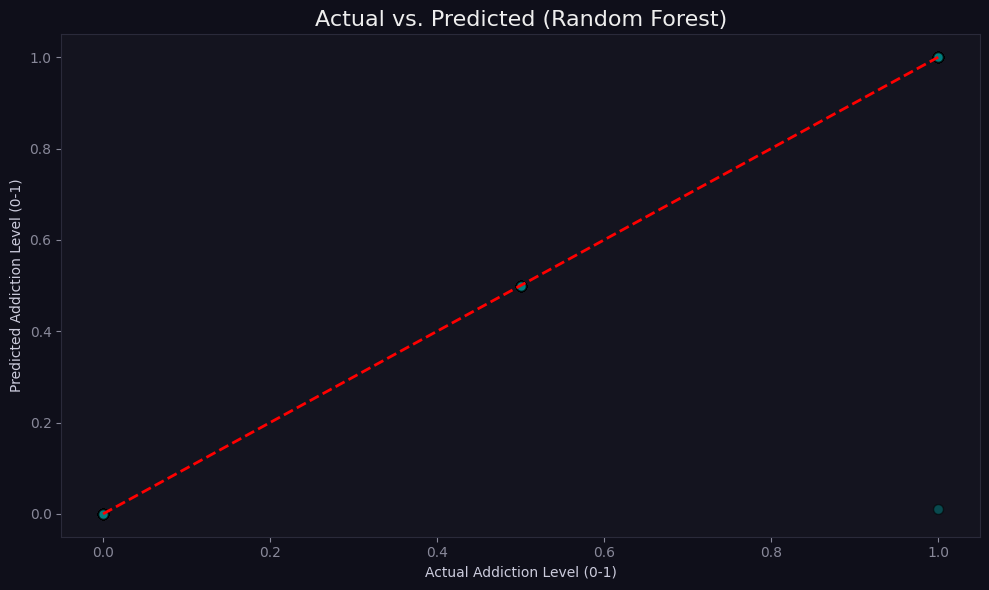

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#models
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor


#spliting the target column 
X = df_encoded.drop('addiction_level', axis=1)
y = df_encoded['addiction_level']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#adding the model 
models ={
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='rmse')
}

results = {}

print(f"{'Model':<30} | {'MAE':<10} | {'RMSE':<10} | {'R2 Score':<10}")
print("-"*75)


for name, model in models.items():
    #training
    model.fit(X_train, y_train)
    #predicting
    y_pred = model.predict(X_test)

    #evaluation
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    #Storing results
    results[name] = {
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Predictions': y_pred
    }
    print(f"{name:<30} | {mae:<10.4f} | {rmse:<10.4f} | {r2:<10.4f}")

best_model = max(results, key= lambda k: results[k]['R2'])


plt.figure(figsize=(10,6))
y_true = y_test.values
y_pred_best = results[best_model]['Predictions']

plt.scatter(y_true, y_pred_best, alpha=0.5, color='teal', edgecolors='k', s=50)
plt.plot([0, 1], [0, 1], 'r--', lw=2) 
plt.title(f'Actual vs. Predicted ({best_model})', fontsize=16)
plt.xlabel('Actual Addiction Level (0-1)')
plt.ylabel('Predicted Addiction Level (0-1)')
plt.tight_layout()
plt.show()

    
    

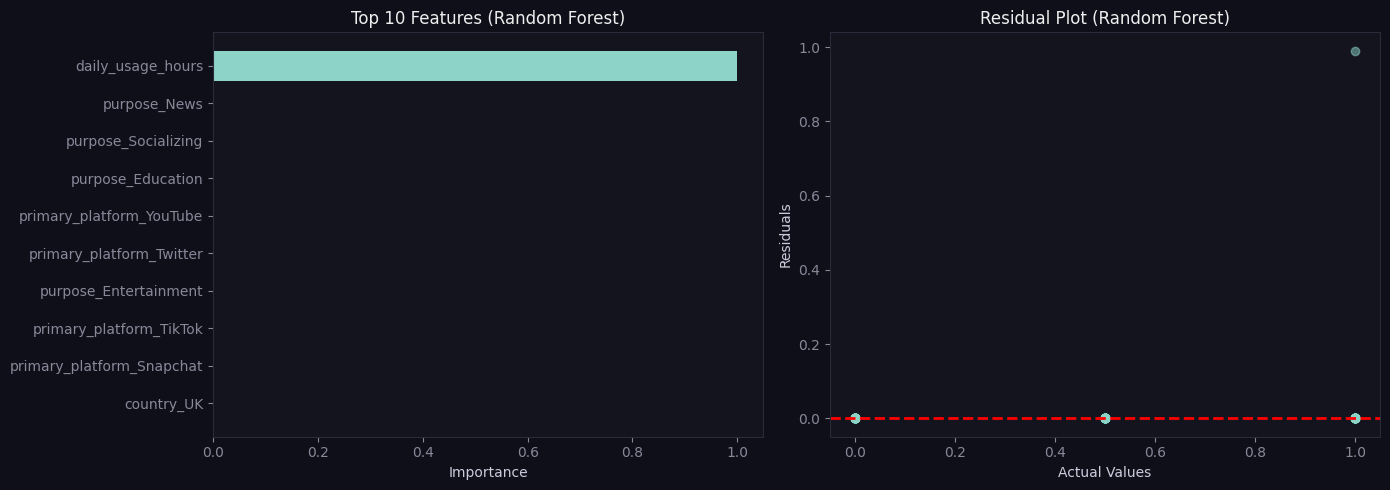

In [26]:
# Feature importance для лучшей модели (если поддерживает)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Для Random Forest или Gradient Boosting
if best_model in ["Random Forest", "Gradient Boosting", "XGBoost"]:
    best_model_obj = models[best_model]
    feature_importance = best_model_obj.feature_importances_
    
    # Сортируем
    sorted_idx = np.argsort(feature_importance)[::-1][:10]  # top 10
    
    axes[0].barh(range(len(sorted_idx)), feature_importance[sorted_idx][::-1])
    axes[0].set_yticks(range(len(sorted_idx)))
    axes[0].set_yticklabels([X.columns[i] for i in sorted_idx][::-1])
    axes[0].set_title(f'Top 10 Features ({best_model})')
    axes[0].set_xlabel('Importance')

# Для линейных моделей - коэффициенты
elif best_model in ["Linear Regression", "Ridge Regression", "Lasso Regression"]:
    coef = models[best_model].coef_
    top_coef_idx = np.argsort(np.abs(coef))[-10:]
    
    axes[0].barh(range(len(top_coef_idx)), coef[top_coef_idx])
    axes[0].set_yticks(range(len(top_coef_idx)))
    axes[0].set_yticklabels([X.columns[i] for i in top_coef_idx])
    axes[0].set_title(f'Top 10 Coefficients ({best_model})')
    axes[0].set_xlabel('Coefficient Value')

# График остатков
residuals = y_test - results[best_model]['Predictions']
axes[1].scatter(y_test, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Actual Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title(f'Residual Plot ({best_model})')

plt.tight_layout()
plt.show()

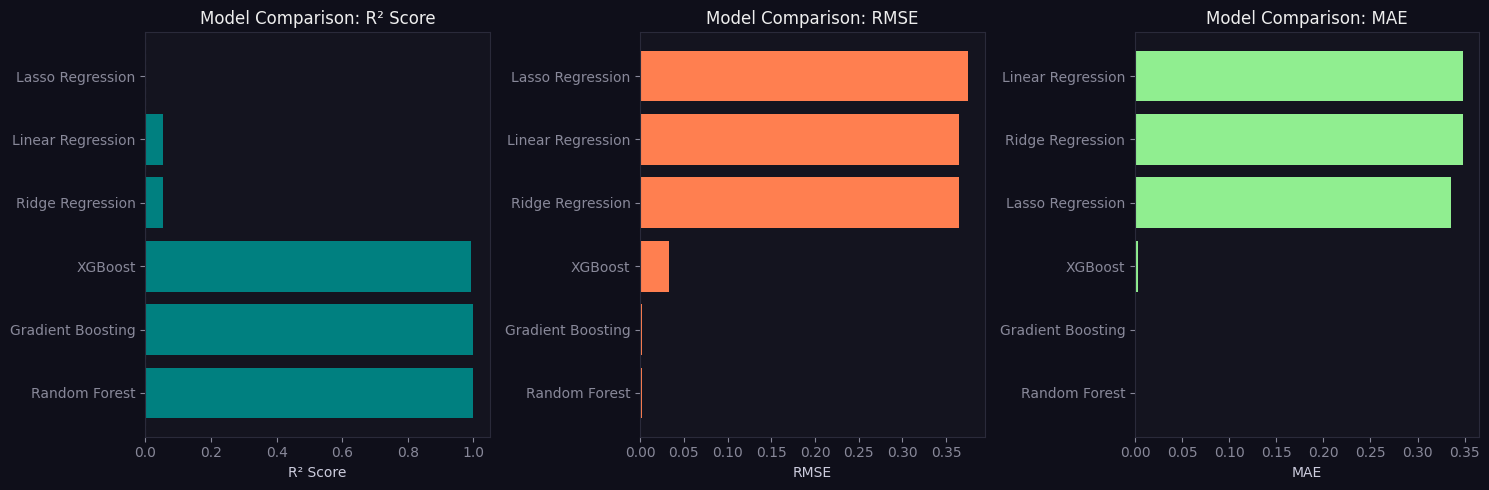


🏆 Best Model: Random Forest
   R² Score: 1.0000
   RMSE: 0.0022
   MAE: 0.0000


In [27]:
# Сравнение моделей
metrics_df = pd.DataFrame({
    name: [results[name]['R2'], results[name]['RMSE'], results[name]['MAE']]
    for name in results.keys()
}, index=['R2', 'RMSE', 'MAE']).T

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# R² Score
metrics_df_sorted = metrics_df.sort_values('R2', ascending=False)
axes[0].barh(metrics_df_sorted.index, metrics_df_sorted['R2'], color='teal')
axes[0].set_xlabel('R² Score')
axes[0].set_title('Model Comparison: R² Score')
axes[0].axvline(x=0, color='gray', linestyle='--', alpha=0.5)

# RMSE
metrics_df_sorted = metrics_df.sort_values('RMSE')
axes[1].barh(metrics_df_sorted.index, metrics_df_sorted['RMSE'], color='coral')
axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE')

# MAE
metrics_df_sorted = metrics_df.sort_values('MAE')
axes[2].barh(metrics_df_sorted.index, metrics_df_sorted['MAE'], color='lightgreen')
axes[2].set_xlabel('MAE')
axes[2].set_title('Model Comparison: MAE')

plt.tight_layout()
plt.show()

print(f"\n🏆 Best Model: {best_model}")
print(f"   R² Score: {results[best_model]['R2']:.4f}")
print(f"   RMSE: {results[best_model]['RMSE']:.4f}")
print(f"   MAE: {results[best_model]['MAE']:.4f}")